# **Predicción de delitos por series temporales**

El enfoque será forecasting tabular con XGBoost y Prophet en paralelo.

# **1. Librerias**

In [1]:
import os
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
import os, sys, math, gc


import warnings
warnings.filterwarnings("ignore")

In [2]:
!{sys.executable} -m pip install kneed
!{sys.executable} -m pip install prophet
from kneed import KneeLocator


# **2. CONFIGURACIÓN DEL AMBIENTE**


## 2.1 VARIABLES GLOBALES

In [3]:
# Semilla global para reproducibilidad
SEED = 42

# Le indicamos a Pandas que siempre muestre hasta 50 columnas completas en lugar de cortarlas con “...”.
pd.set_option("display.max_columns", 50)

## 2.2 ACCESO A DATOS

In [4]:
# ---- Switch de entorno: "colab" o "local"
RUN_ENV = "local"   # <-- cambia a "local" si no usas Google Colab

# ---- Rutas base
if RUN_ENV.lower() == "colab":
    try:
        from google.colab import drive
        drive.mount("/drive")
    except Exception as e:
        print("Aviso: no se pudo montar Drive automáticamente:", e)
    # Ajusta esta ruta a tu carpeta del proyecto en Drive
    BASE_DIR = "/drive/My Drive/Colab Notebooks/reto-Thales/"
else:
    # Ajusta a tu ruta local del proyecto
    BASE_DIR = "/Users/jorgevalverde/Documents/myEnv/crimen-cdmx/"

os.makedirs(BASE_DIR, exist_ok=True)

# Ruta de los modelos
DATA_DIR = os.path.join(BASE_DIR, "data")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
MODELS_DIR = os.path.join(RESULTS_DIR, "final_models")

print(f"Entorno: {RUN_ENV} | BASE_DIR: {BASE_DIR}")

Entorno: local | BASE_DIR: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/


In [5]:
# Vamos utilizar un archivo de funciones propio
#sys.path.insert(0, BASE_DIR) #para acceder desde Colab-Drive
import myUtils as myUtils

# **3. DATOS**

In [6]:
DATA_PATH = os.path.join(BASE_DIR, "data", "delitos_cdmx_sample_final_5percent.csv")

In [7]:
# Lectura de datos crudos
df = pd.read_csv(DATA_PATH, parse_dates=["fecha_hecho", "fecha_inicio"], dayfirst=True, low_memory=False)
df = myUtils.apply_dtypes(df, verbose=True) 
df["fecha_inicio"] = pd.to_datetime(df.get("fecha_inicio"), errors="coerce", dayfirst=True)
df["fecha_hecho"]  = pd.to_datetime(df.get("fecha_hecho"),  errors="coerce", dayfirst=True)

df

Columnas esperadas totales: 21
No faltan columnas esperadas.

Resumen de casting:
• A string: 15 columnas → ['delito', 'categoria_delito', 'competencia', 'fiscalia', 'agencia', 'unidad_investigacion', 'colonia_hecho', 'colonia_catalogo', 'alcaldia_hecho', 'alcaldia_catalogo', 'municipio_hecho', 'hora_inicio', 'hora_hecho', 'mes_inicio', 'mes_hecho']
• A Int64: ['anio_inicio', 'anio_hecho']
• A Float64: ['latitud', 'longitud']
• A datetime64[ns]: ['fecha_inicio', 'fecha_hecho']
   - 'fecha_inicio': no nulos antes = 209872, NaT después = 129812
   - 'fecha_hecho': no nulos antes = 209819, NaT después = 127987


,anio_inicio,mes_inicio,fecha_inicio,hora_inicio,anio_hecho,mes_hecho,fecha_hecho,hora_hecho,delito,competencia,fiscalia,agencia,unidad_investigacion,colonia_hecho,colonia_catalogo,alcaldia_hecho,alcaldia_catalogo,municipio_hecho,latitud,longitud,categoria_delito
0,2016,Mayo,2016-10-05,00:00:00,2016,Abril,2016-03-04,12:28:00,AMENAZAS,<NA>,INVESTIGACIÓN EN COYOACÁN,COY-1,UI-1CD,CULHUACÁN CTM SECCIÓN V,Culhuacan Ctm Seccion I,COYOACAN,<NA>,CDMX,19.33182,-99.11862,delito de bajo impacto
1,2016,Mayo,NaT,00:00:00,2016,Mayo,NaT,15:10:00,LESIONES CULPOSAS POR TRANSITO VEHICULAR EN CO...,<NA>,INVESTIGACIÓN EN CUAUHTEMOC,CUH-2,UI-3CD,DOCTORES,Doctores,CUAUHTEMOC,<NA>,CDMX,19.4248,-99.14254,delito de bajo impacto
2,2016,Julio,2016-07-07,00:00:00,2016,Mayo,NaT,02:00:00,ROBO DE OBJETOS,<NA>,INVESTIGACIÓN EN CUAUHTEMOC,CUH-2,UI-2SD,SANTA MARIA LA RIBERA,Santa Maria La Ribera,CUAUHTEMOC,<NA>,CDMX,19.44337,-99.15801,delito de bajo impacto
3,2016,Enero,2016-04-01,00:00:00,2016,Enero,2016-04-01,15:30:00,PERDIDA DE LA VIDA POR OTRAS CAUSAS,<NA>,INVESTIGACIÓN EN CUAUHTEMOC,CUH-8,UI-3CD,ESPERANZA,Esperanza,CUAUHTEMOC,<NA>,CDMX,19.42177,-99.12674,hecho no delictivo
4,2016,Febrero,2016-08-02,00:00:00,2016,Febrero,2016-01-02,14:00:00,VIOLENCIA FAMILIAR,<NA>,INVESTIGACIÓN EN XOCHIMILCO,XO-2,UI-2SD,LA JOYA,<NA>,XOCHIMILCO,<NA>,CDMX,19.231226,-99.095951,delito de bajo impacto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209868,2025,Enero,NaT,16:25:45:00,2025,Enero,NaT,14:00:00:00,VIOLENCIA FAMILIAR,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN TLALPAN,UAT-TLP-5,UI-1SD,PEDREGAL DE AMINCO,Pueblo San Francisco Tlalnepantla,TLALPAN,<NA>,CDMX,19.201846,-99.131102,delito de bajo impacto
209869,2025,Enero,NaT,17:56:48:00,2025,Enero,NaT,14:58:00:00,VIOLENCIA FAMILIAR,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN TLALPAN,TLP-3,UI-1CD,SAN MIGUEL TOPILEJO,Pueblo San Miguel Topilejo,TLALPAN,<NA>,CDMX,19.191853,-99.141353,delito de bajo impacto
209870,2025,Enero,NaT,02:13:04:00,2024,Diciembre,NaT,06:00:00:00,ROBO A PASAJERO A BORDO DE METRO SIN VIOLENCIA,FUERO COMUN,AGENCIA DE DENUNCIA DIGITAL,CEN-A,UI-1SD,SANTA MARIA NONOALCO,Santa Maria Nonoalco,BENITO JUAREZ,<NA>,CDMX,19.384536,-99.186575,OTRAS
209871,2025,Enero,NaT,23:51:01:00,2022,Enero,NaT,12:00:00:00,DESPOJO,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN COYOACÁN,COY-1,UI-2CD,ROMERO DE TERREROS,Romero De Terreros,COYOACAN,<NA>,CDMX,19.343661,-99.168056,delito de bajo impacto


In [8]:
print("Shape inicial:", df.shape)
print(df[["fecha_hecho", "fecha_inicio"]].head())

Shape inicial: (209873, 21)
  fecha_hecho fecha_inicio
0  2016-03-04   2016-10-05
1         NaT          NaT
2         NaT   2016-07-07
3  2016-04-01   2016-04-01
4  2016-01-02   2016-08-02


Puntos clave:

- Mantener las fechas en datetime64.

- Validar columnas críticas: "categoria_delito", "delito", "latitud", "longitud", "alcaldia_hecho", "colonia_hecho".

- Filtrar filas con coordenadas o fechas nulas si fuese necesario.

# **4. DIVISIÓN TEMPORAL DE LOS DATOS**

Evitar data leakage temporal y reflejar condiciones reales (predecir el futuro desde el pasado).

Se realizará lo siguiente:

- Ordenar por fecha_hecho

- Usar:

  - Train: primeros 80 % del tiempo
  - Test: últimos 20 %

- Luego se podrá crear ventanas deslizantes (rolling origin), necesarias para Prophet o XGBoost.

In [9]:
# División temporal robusta (con fallback para reducir NaT)
df_train, df_test, cutoff_date = myUtils.split_time_series(
    df,
    date_col="fecha_hecho",
    test_ratio=0.2,
    fallback_date_col="fecha_inicio",  # <- usa fecha_inicio donde falte fecha_hecho
    drop_na=True,
    verbose=True
)

División temporal completada:
  • Fechas completadas desde 'fecha_inicio': 19060
  • Filas con NaT antes: 108927 / 209873 (51.9%)
  • Filas eliminadas por NaT: 108927 (quedan 100946)
  • Train: 80756 filas (hasta 2023-01-08 00:00:00)
  • Test : 20190 filas (desde 2023-01-08 00:00:00)


In [10]:
df_train

,anio_inicio,mes_inicio,fecha_inicio,hora_inicio,anio_hecho,mes_hecho,fecha_hecho,hora_hecho,delito,competencia,fiscalia,agencia,unidad_investigacion,colonia_hecho,colonia_catalogo,alcaldia_hecho,alcaldia_catalogo,municipio_hecho,latitud,longitud,categoria_delito
14285,2016,Junio,NaT,00:00:00,1915,Enero,1915-10-01,15:00:00,FRAUDE,<NA>,INVESTIGACIÓN EN XOCHIMILCO,XO-1,UI-3CD,BOSQUE RESIDENCIAL DEL SUR,Bosque Residencial Del Sur,XOCHIMILCO,<NA>,CDMX,19.28277,-99.12522,delito de bajo impacto
119411,2021,Diciembre,2021-03-12,00:00:00,1917,Septiembre,1917-01-09,01:00:00,USURPACIÓN DE IDENTIDAD,FUERO COMUN,AGENCIA DE DENUNCIA DIGITAL,CEN-1,Unidad de Investigación 1 S/D,SAN RAFAEL,San Rafael,CUAUHTEMOC,<NA>,CDMX,19.43801,-99.16431,delito de bajo impacto
152124,2022,Junio,2022-09-06,00:00:00,1955,Junio,1955-07-06,16:00:00,COBRANZA ILEGITIMA,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN TLALPAN,UAT-TLP-3,UI-1SD,ISIDRO FABELA,Isidro Fabela,TLALPAN,<NA>,CDMX,19.29974,-99.17246,delito de bajo impacto
11631,2016,Febrero,2016-08-02,00:00:00,1955,Febrero,1955-08-02,04:55:00,ROBO A PASAJERO / CONDUCTOR DE TAXI CON VIOLENCIA,<NA>,INVESTIGACIÓN EN CUAUHTEMOC,CUH-2,UI-1CD,MAZA,Valle Gomez,CUAUHTEMOC,<NA>,CDMX,19.457313,-99.126835,delito de bajo impacto
15266,2016,Junio,NaT,00:00:00,1962,Diciembre,1962-11-12,11:00:00,ALLANAMIENTO DE MORADA,<NA>,INVESTIGACIÓN EN BENITO JUÁREZ,URI-BJ-4,UI-1SD,INSURGENTES MIXCOAC,Insurgentes Mixcoac,BENITO JUAREZ,<NA>,CDMX,19.37183,-99.18148,delito de bajo impacto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200238,2024,Junio,2024-07-06,13:22:00,2023,Agosto,2023-01-08,12:00:00,ABUSO SEXUAL,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN DE DELITOS COMETIDOS...,E,<NA>,SAN GREGORIO ATLAPULCO,Pueblo San Luis Tlaxialtemalco,XOCHIMILCO,<NA>,CDMX,19.260839,-99.028934,delito de bajo impacto
169629,2023,Agosto,2023-01-08,12:52:37,2023,Agosto,2023-01-08,12:00:00,VIOLENCIA FAMILIAR,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN DEL DELITO DE VIOLEN...,75,Unidad de investigación 7 S/D,<NA>,<NA>,CDMX (indeterminada),CDMX (indeterminada),CDMX,<NA>,<NA>,delito de bajo impacto
165293,2023,Agosto,2023-12-08,12:25:21,2023,Agosto,2023-01-08,12:05:00,FRAUDE,FUERO COMUN,AGENCIA DE DENUNCIA DIGITAL,CEN-B,UI-1SD,ZEDEC SANTA FE,Santa Fe Centro Ciudad,ALVARO OBREGON,<NA>,CDMX,19.36599,-99.266008,delito de bajo impacto
168233,2023,Agosto,2023-01-08,18:20:54,2023,Agosto,2023-01-08,10:33:00,DAÑO EN PROPIEDAD AJENA CULPOSA POR TRÁNSITO V...,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN MIGUE...,UAT-MH-4,UI-1SD,BOSQUE DE CHAPULTEPEC I SECCIÓN,Bosque De Chapultepec I Seccion,MIGUEL HIDALGO,<NA>,CDMX,19.424648,-99.185387,delito de bajo impacto


In [11]:
df_test

,anio_inicio,mes_inicio,fecha_inicio,hora_inicio,anio_hecho,mes_hecho,fecha_hecho,hora_hecho,delito,competencia,fiscalia,agencia,unidad_investigacion,colonia_hecho,colonia_catalogo,alcaldia_hecho,alcaldia_catalogo,municipio_hecho,latitud,longitud,categoria_delito
184725,2023,Agosto,2023-01-08,18:53:58,2023,Julio,2023-01-08,21:00:00,VIOLENCIA FAMILIAR,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN DEL DELITO DE VIOLEN...,CJM-TLP,3 SIN DETENIDO,SAN ANDRÉS TOTOLTEPEC,Pueblo San Andres Totoltepec,TLALPAN,<NA>,CDMX,19.250515,-99.174372,delito de bajo impacto
161126,2023,Agosto,2023-08-08,11:15:38,2023,Agosto,2023-01-08,00:00:00,FRAUDE,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN ESTRATÉGICA DE DELIT...,T,UI-1SD,<NA>,<NA>,CDMX (indeterminada),CDMX (indeterminada),CDMX,<NA>,<NA>,delito de bajo impacto
189444,2024,Agosto,NaT,16:14:00,2023,Agosto,2023-01-08,12:00:00,ABUSO SEXUAL,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN DE DELITOS SEXUALES,FDS-6,FDS-6-03,<NA>,<NA>,CUAUHTEMOC,<NA>,CDMX,<NA>,<NA>,delito de bajo impacto
165917,2023,Agosto,2023-01-08,08:43:04,2023,Agosto,2023-01-08,00:00:00,VIOLENCIA FAMILIAR,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN MIGUE...,UAT-MH-1,UI-1SD,LEGARIA,Tacuba,MIGUEL HIDALGO,<NA>,CDMX,19.457332,-99.191703,delito de bajo impacto
184805,2023,Agosto,2023-03-08,13:24:25,2023,Agosto,2023-01-08,18:48:00,MALTRATO ANIMAL,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN EN DELITOS AMBIENTAL...,A,2 CON DETENIDO 2 C/D,SAN ANTONIO,Valle De San Lorenzo,IZTAPALAPA,<NA>,CDMX,19.303509,-99.076858,delito de bajo impacto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190264,2024,Octubre,2024-12-10,10:06:00,2024,Junio,2024-12-10,09:00:00,QUEBRANTAMIENTO DE SELLOS,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN CUAJI...,UAT-CUJ-1,UI-1SD,EL YAQUI,Ampliacion El Yaqui,CUAJIMALPA DE MORELOS,<NA>,CDMX,19.36122,-99.283568,delito de bajo impacto
202029,2024,Octubre,NaT,02:42:00,2024,Octubre,2024-12-10,17:00:00,ROBO DE VEHICULO DE SERVICIO PARTICULAR SIN VI...,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN TLALPAN,UAT-TLP-5,UI-1SD,PARRES EL GUARDA,<NA>,TLALPAN,<NA>,CDMX,19.130036,-99.179986,robo de vehiculo con y sin violencia
205967,2024,Octubre,NaT,10:11:00,2024,Octubre,2024-12-10,08:00:00,PERSONAS EXTRAVIADAS Y AUSENTES,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN TLÁHUAC,UAT-TLH-1,3 SIN DETENIDO,CENTRO,Centro,CUAUHTEMOC,<NA>,CDMX,19.427475,-99.152374,delito de bajo impacto
187404,2024,Octubre,2024-12-10,15:43:00,2024,Septiembre,2024-12-10,16:08:00,VIOLENCIA FAMILIAR,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN TLÁHUAC,UAT-TLH-1,3 SIN DETENIDO,<NA>,<NA>,CDMX (indeterminada),CDMX (indeterminada),CDMX,<NA>,<NA>,delito de bajo impacto


In [12]:
cutoff_date

Timestamp('2023-01-08 00:00:00')

# **5. FEATURE ENGINEERING**

Se espera crear un conjunto de features base para cada punto en el tiempo (o celda geográfica) que luego sirvan como insumo a Prophet o XGBoost.

Feature engineering modular:

**Temporal (reutilizable del módulo previo):**

- anio, mes, dia_semana, hora, fin_de_semana, mes_sin, mes_cos, hora_sin, hora_cos

- Pero esta vez basadas solo en fecha_hecho

**Espacial (simplificada):**

- latitud, longitud

- cluster_geo con KMeans (número óptimo clusters)

- densidad_delictiva_1km si deseas medir intensidad local

**Conteo agregado:**

- Número de delitos por (fecha_hecho, cluster_geo, categoria_delito)

- Será la serie temporal base.

## Features Temporales

In [13]:
df_train = myUtils.make_temporal_features(df_train, "fecha_hecho")
df_test = myUtils.make_temporal_features(df_test, "fecha_hecho")

## Features espacio-temporales

In [14]:
coords = df.copy().dropna(subset=["latitud", "longitud"])[["latitud", "longitud"]].to_numpy()
inertia = []

K = range(2, 21)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    kmeans.fit(coords)
    inertia.append(kmeans.inertia_)

kneedle = KneeLocator(K, inertia, curve="convex", direction="decreasing") # regla del codo
k_optimo = kneedle.knee 

df_train, df_agg_train, kmeans_model = myUtils.aggregate_spatial_temporal(df_train, n_clusters=k_optimo)
df_test, df_agg_test, _ = myUtils.aggregate_spatial_temporal(df_test, n_clusters=k_optimo)

Las features son suficientes para modelos "alto nivel" como Prophet. Pero para otros modelos como XGBoost o Sarimax, es necesario considerar otras features como: 

| Tipo                             | Ejemplo                                           | Propósito                                                |
| -------------------------------- | ------------------------------------------------- | -------------------------------------------------------- |
|  **Ventanas móviles**          | `count_rolling_4w`, `count_rolling_8w`            | Captura tendencia y volatilidad local                    |
|  **Lag features**              | `lag_1`, `lag_2`, `lag_4` (semanas anteriores)    | Para modelos tipo XGBoost que no tienen memoria temporal |
|  **Estacionalidad codificada** | `sin_semana`, `cos_semana` (codificación cíclica) | Ayuda a modelos ML a entender periodicidad semanal       |


## Validación de la serie

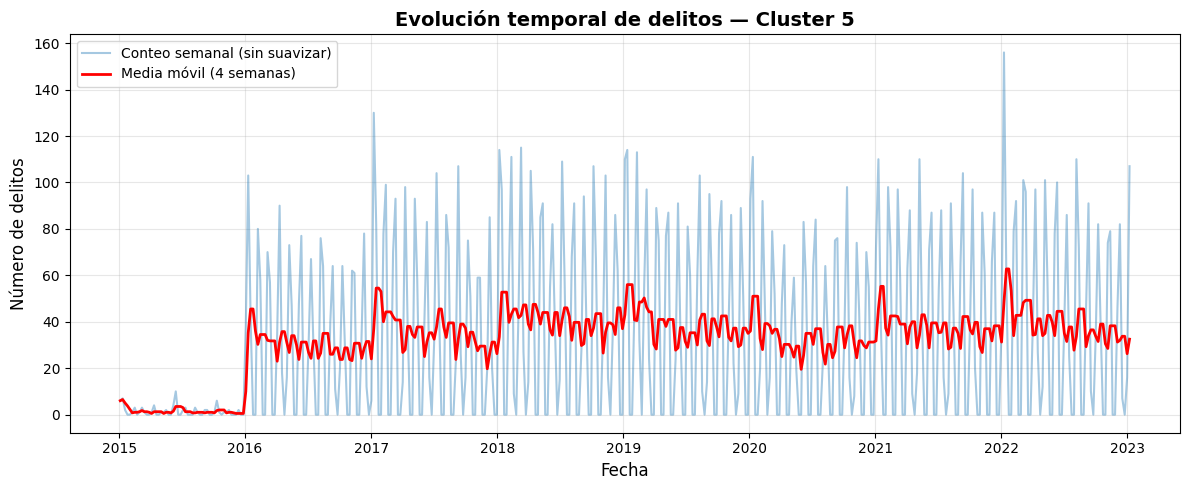

Cluster seleccionado: 5
Rango temporal mostrado: 2015-01-04 → 2023-01-08
Total de semanas en la serie: 419


In [15]:
# Evolución temporal de delitos (filtrado, agregación semanal y suavizado)

# 1) Seleccionar una zona geográfica al azar
zone_sample = np.random.choice(df_agg_train["cluster_geo"].unique())
subset = df_agg_train[df_agg_train["cluster_geo"] == zone_sample].copy()

# 2) Filtrar por rango temporal reciente (a partir de 2015)
subset = subset[subset["fecha_hecho"] >= "2015-01-01"]

# 3) Agregar por semana para reducir ruido diario
subset_weekly = (
    subset.groupby(pd.Grouper(key="fecha_hecho", freq="1W"))["count"]
    .sum()
    .reset_index()
)

# 4) Aplicar suavizado (media móvil de 4 semanas)
subset_weekly["smooth"] = subset_weekly["count"].rolling(window=4, min_periods=1).mean()

# 5) Visualización
plt.figure(figsize=(12, 5))
plt.plot(subset_weekly["fecha_hecho"], subset_weekly["count"], alpha=0.4, label="Conteo semanal (sin suavizar)")
plt.plot(subset_weekly["fecha_hecho"], subset_weekly["smooth"], color="red", linewidth=2, label="Media móvil (4 semanas)")

# Estética y etiquetas
plt.title(f"Evolución temporal de delitos — Cluster {zone_sample}", fontsize=14, weight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Número de delitos", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Reporte complementario
print(f"Cluster seleccionado: {zone_sample}")
print(f"Rango temporal mostrado: {subset_weekly['fecha_hecho'].min():%Y-%m-%d} → {subset_weekly['fecha_hecho'].max():%Y-%m-%d}")
print(f"Total de semanas en la serie: {len(subset_weekly)}")


# 6. PREDICCIÓN CON MODELOS ESPACIO-TEMPORALES


## 6.1 Agregado Semanal de Features

Haremos un agregado de los datos en un período **SEMANAL** porque estamos trabajando con solamente el 5% de los datos originales. Para el proyecto final en el que se trabaje con el 100% de los datos, el agregado de las features debe ser **DIARIO**, pues se contará con la cantidad suficiente de datos.

In [16]:
df_train_w = myUtils.aggregate_weekly(df_train, date_col="fecha_hecho",
                                      group_cols=("cluster_geo","categoria_delito"),
                                      count_col=None)
df_train_w

,cluster_geo,categoria_delito,ds,y
0,0,OTRAS,1992-03-08,0.0
1,0,OTRAS,1992-03-15,0.0
2,0,OTRAS,1992-03-22,0.0
3,0,OTRAS,1992-03-29,0.0
4,0,OTRAS,1992-04-05,0.0
...,...,...,...,...
47765,5,robo de vehiculo con y sin violencia,2022-12-04,0.0
47766,5,robo de vehiculo con y sin violencia,2022-12-11,0.0
47767,5,robo de vehiculo con y sin violencia,2022-12-18,0.0
47768,5,robo de vehiculo con y sin violencia,2022-12-25,0.0


In [17]:
df_test_w  = myUtils.aggregate_weekly(df_test,  date_col="fecha_hecho",
                                      group_cols=("cluster_geo","categoria_delito"),
                                      count_col=None)
df_test_w

,cluster_geo,categoria_delito,ds,y
0,0,OTRAS,2023-01-15,0.0
1,0,OTRAS,2023-01-22,0.0
2,0,OTRAS,2023-01-29,0.0
3,0,OTRAS,2023-02-05,0.0
4,0,OTRAS,2023-02-12,0.0
...,...,...,...,...
3492,5,robo de vehiculo con y sin violencia,2024-11-03,0.0
3493,5,robo de vehiculo con y sin violencia,2024-11-10,0.0
3494,5,robo de vehiculo con y sin violencia,2024-11-17,0.0
3495,5,robo de vehiculo con y sin violencia,2024-11-24,0.0


## 6.2 Prophet

In [18]:
# -------------------------
#   Prophet (por serie)
#   Horizonte: 2 semanas (~48h no es semanal; para “48h” usa 2 días en Prophet
#   pero aquí mantenemos semanal para el flujo.)
# -------------------------
prophet_models, prophet_fcst = myUtils.prophet_forecast_per_series(
    df_w=df_train_w,
    group_cols=("cluster_geo","categoria_delito"),
    horizon_weeks=1,           # 1 semana hacia adelante
    yearly=True, weekly=True, daily=False,
    seasonality_mode="additive"
)
print("Prophet: predicciones semanales por serie:")
prophet_fcst

Prophet: predicciones semanales por serie:


,ds,yhat,yhat_lower,yhat_upper,cluster_geo,categoria_delito
0,2023-01-08,0.0,-1.292128e-09,1.213994e-09,0,OTRAS
1,2023-01-08,0.0,-1.200002e-09,1.319732e-09,0,delito de bajo impacto
2,2023-01-08,0.0,-1.205494e-09,1.394875e-09,0,hecho no delictivo
3,2023-01-08,0.0,-1.291108e-09,1.240555e-09,0,robo a negocio con violencia
4,2023-01-08,0.0,-1.355874e-09,1.293368e-09,0,robo a transeunte en via publica con y sin vio...
5,2023-01-08,0.0,-1.295671e-09,1.343587e-09,0,robo de vehiculo con y sin violencia
6,2023-01-01,0.0,-1.194452e-09,1.294050e-09,1,OTRAS
7,2023-01-08,0.0,-1.298977e-09,1.325224e-09,1,delito de bajo impacto
8,2022-12-11,0.0,-1.201206e-09,1.246401e-09,1,hecho no delictivo
9,2022-10-09,0.0,-1.329893e-09,1.324441e-09,1,robo a negocio con violencia


Considerar que:

| Columna                     | Significado                                                                |
| --------------------------- | -------------------------------------------------------------------------- |
| **ds**                      | Fecha futura del pronóstico (una semana después del último dato entrenado) |
| **yhat**                    | Valor pronosticado (conteo esperado de delitos esa semana)                 |
| **yhat_lower / yhat_upper** | Intervalo de confianza (rango probable)                                    |
| **cluster_geo**             | Zona geográfica o clúster espacial                                         |
| **categoria_delito**        | Tipo de delito (la serie que Prophet entrenó)                              |


Observamaos que todas las predicciones están en 0.0. Esto ocurre cuando toda la serie histórica que Prophet vio era casi todo ceros.
Prophet detecta que no hay variación temporal y ajusta una línea constante con valor ≈0.
Por eso también los intervalos yhat_lower y yhat_upper están alrededor de cero con valores ínfimos (~1e-9).<br>

No es un error técnico — el modelo funcionó, solo que los datos no tienen dinámica detectable.<br>

Prophet está “diciendo”: no hay evidencia estadística de que el conteo cambie semana a semana, por tanto el mejor pronóstico es 0.

## 6.3 XGBoost

In [19]:
#  XGBoost (global, con lags/rolling)

# 1) Crear features en TRAIN
train_feat = myUtils.add_lag_and_rolling_features(
    df_w=df_train_w,
    group_cols=("cluster_geo","categoria_delito"),
    target_col="y",
    lags=(1,2,4),
    windows=(4,8)
)

# 2) Entrenar
xgb_model, xgb_features = myUtils.fit_xgb_weekly(
    df_feat=train_feat,
    group_cols=("cluster_geo","categoria_delito"),
    target_col="y",
    feature_cols=None,   # auto: usa lags/rolling + w_sin/w_cos
    params=dict(n_estimators=400, learning_rate=0.05, max_depth=6),
    random_state=42
)
print("XGB features:", xgb_features)

XGB features: ['lag_1w', 'lag_2w', 'lag_4w', 'roll_mean_4w', 'roll_std_4w', 'roll_mean_8w', 'roll_std_8w', 'w_sin', 'w_cos']


In [20]:
# 3) Preparar TEST con las MISMAS features (se calculan sobre train+test para que lags existan)
#    Unimos para construir lags/rolling de forma continua y luego separamos por fecha.
both = pd.concat([df_train_w.assign(split="train"),
                  df_test_w.assign(split="test")], ignore_index=True)

both_feat = myUtils.add_lag_and_rolling_features(
    df_w=both,
    group_cols=("cluster_geo","categoria_delito"),
    target_col="y",
    lags=(1,2,4),
    windows=(4,8)
)


In [21]:
test_feat = both_feat[both_feat["split"]=="test"].copy()
xgb_fcst = myUtils.xgb_forecast_next_weeks(
    model=xgb_model,
    df_feat_future=test_feat,   # aquí también puede ser un “horizonte futuro” fabricado
    feature_cols=xgb_features,
    group_cols=("cluster_geo","categoria_delito")
)
print("XGB → sample pred:")
display(xgb_fcst.head())

XGB → sample pred:


,cluster_geo,categoria_delito,ds,yhat
47770,0,OTRAS,2023-01-15,0.0
47771,0,OTRAS,2023-01-22,0.0
47772,0,OTRAS,2023-01-29,0.0
47773,0,OTRAS,2023-02-05,0.0
47774,0,OTRAS,2023-02-12,0.0


## 6.4 Sarimax

In [22]:
# SARIMAX (por serie)
sarimax_models, sarimax_fcst = myUtils.sarimax_forecast_per_series(
    df_w=df_train_w,
    group_cols=("cluster_geo","categoria_delito"),
    order=(1,1,1),
    seasonal_order=(1,1,1,52),  # semanal
    horizon_weeks=1
)

print("SARIMAX → predicciones semanales por serie:")
display(sarimax_fcst.head())

SARIMAX → predicciones semanales por serie:


,ds,yhat,cluster_geo,categoria_delito
0,2023-01-08,0.0,0,OTRAS
1,2023-01-08,0.0,0,delito de bajo impacto
2,2023-01-08,0.0,0,hecho no delictivo
3,2023-01-08,0.0,0,robo a negocio con violencia
4,2023-01-08,0.0,0,robo a transeunte en via publica con y sin vio...


## 6.5 Visualización

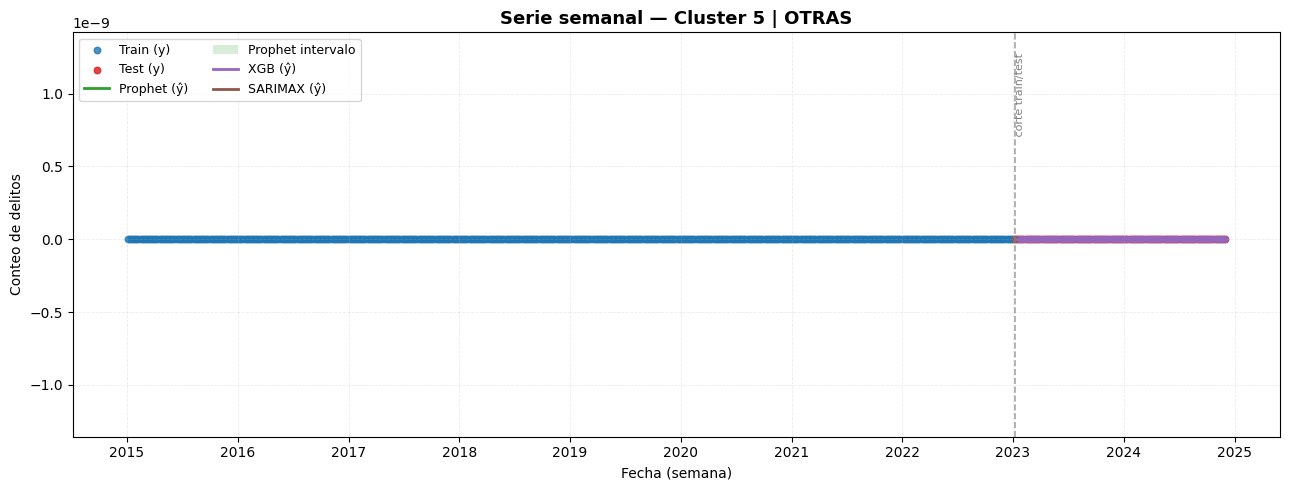

In [23]:
# Elegimos zona/categoría a visualizar
zone = zone_sample
cat  = "OTRAS"  # usa una de tus clases

# Diccionario de predicciones por modelo (usa los que ya tengas)
model_preds = {
    "Prophet": prophet_fcst,   # si no lo tienes, quítalo del dict
    "XGB": xgb_fcst,
    "SARIMAX": sarimax_fcst   # idem
}

myUtils.plot_train_test_predictions(
    df_train_w=df_train_w,
    df_test_w=df_test_w,
    model_preds=model_preds,
    cluster_id=zone,
    categoria=cat,
    show_intervals=True,
    figsize=(13, 5)
)